# Problem

**State space.**
The states are encoded as integers
$$\mathcal{X} = {0,1,\dots,8} $$
corresponding to the grid in row-major order (top-left corner to bottom-right corner). State $8$ is the terminal goal state and is absorbing.

**Action space.**
Actions are represented as integers

$$ \mathcal{A} = {0,1,2,3} $$

where $0 =$ Up, $1 =$ Down, $2 =$ Left, $3 =$ Right.

**Transition dynamics.**
Transitions are deterministic. For any state $x$ and action $a$, the state index is first mapped to its grid coordinates $(r,c)$, the action moves the agent one step (unless this would leave the grid), and the result is mapped back to a state index. The goal state $8$ always transitions to itself.
The transition matrix $P$ has shape $(|\mathcal{X}||\mathcal{A}|) \times |\mathcal{X}| = 36 \times 9$, where each row corresponds to a pair $(x,a)$ and contains a one-hot vector indicating the unique next state:

$$P[(x,a),x'] = 1 \quad \text{iff } x' = \text{next\_state}(x,a)$$

and $0$ otherwise.

**Reward model.**
Thus $r(x,a) = 1$ only when $x$ is the goal state, and $0$ otherwise.

**Initial state.**
The initial state is fixed as $x_0 = 0$.

In [2]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "generalization"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Add project root to the Python path
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.mdp import DiscreteMDP, Planner
from rl_methods.fogas import FOGASEvaluator, FOGASHyperOptimizer
from rl_methods.fogas_generalization import *

/home/mauro/anaconda3/envs/fogas/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Problem

In [3]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9
x_0 = 0

dataset_path = DATASETS_DIR / "3grid.csv"
goal_grid = 8


def phi(x, a):
    vec = torch.zeros(N * A, dtype=torch.float64, device=DEVICE)
    vec[int(x) * A + int(a)] = 1.0
    return vec


omega = torch.full(
    (N * A,),
    -0.1,
    dtype=torch.float64,
    device=DEVICE,
)
omega[goal_grid * A : goal_grid * A + A] = 1.0


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:      # Up
        r = max(0, r - 1)
    elif a == 1:    # Down
        r = min(2, r + 1)
    elif a == 2:    # Left
        c = max(0, c - 1)
    elif a == 3:    # Right
        c = min(2, c + 1)

    return to_s(r, c)


def psi(xp):
    v = torch.zeros(N * A, dtype=torch.float64, device=DEVICE)
    for x in states:
        for a in actions:
            if next_state(x, a) == int(xp):
                v[int(x) * A + int(a)] = 1.0
    return v


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    phi=phi,
    omega=omega,
    psi=psi,
    terminal_states=[goal_grid],
).to(DEVICE)

planner = Planner(mdp)

## Beta

In [12]:
solver_e = VBetaSolver(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,
    print_params=True,
    T=2000,
    seed=SEED,
    device=DEVICE,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal_grid],
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets/3grid.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      462.7564263195183
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000621
rho:                            870.919017
eta:                            0.000012
D_theta:                    18.973666
beta (ridge):             0.000014
D_pi (derived):           23.548200




In [ ]:
summary = optimizer_e.optimize(
    mode="grid",
    parameters=("eta", "rho", "alpha", "D_theta"),
    values={
        "alpha": [6e-4, 1e-3, 1e-2, 1e-1, 1.0],
        "eta": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0],
    },
    num_runs=1,
    plot=False,
    print_summary=True,
    progress=True,
    results_output=RESULTS_DIR / "3grid_vbeta.csv",
)

eta_star = summary["best_params"]["eta"]
rho_star = summary["best_params"]["rho"]
alpha_star = summary["best_params"]["alpha"]
D_theta_star = summary["best_params"]["D_theta"]

FOGAS hyperopt:   0%|          | 0/875 [00:00<?, ?candidate/s]

FOGAS hyperopt: 100%|██████████| 875/875 [12:00<00:00,  1.21candidate/s, stage=grid, metric=0.878, best=0.344]


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('eta', 'rho', 'alpha', 'D_theta')
Evaluated candidates: 875
Best metric: 0.3439
Best params: alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=1.0000e+00, D_pi=2.0000e+02

Top 5 candidates:
1. metric=0.3439 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=1.0000e+00, D_pi=2.0000e+02
2. metric=0.3439 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=5.0000e+00, D_pi=1.0000e+03
3. metric=0.3439 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=1.0000e+01, D_pi=2.0000e+03
4. metric=0.3439 | stage=grid | alpha=1.0000e-01, rho=1.0000e-02, eta=1.0000e-01, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+03
5. metric=0.3439 | stage=grid | alpha=1.0000e-01, rho=1.0000e-01, eta=1.0000e-01, T=2000, D_theta=1.0000e+00, D_pi=2.0000e+02


In [18]:
solver_e.run(
    alpha=1e-1,
    eta=1e-1,
    rho=1e-2,
    D_theta=1,
    T=2000,
    tqdm_print=True,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=5,
    seed=SEED,
    terminal_states=[goal_grid],
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

FOGAS:   0%|          | 0/2000 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 2000/2000 [00:01<00:00, 1198.86it/s]


========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  6.217100 | delta = -9.784109e-08
State 1: V*(x) =  7.019000 | V^pi(x) =  7.019000 | delta = -1.978343e-08
State 2: V*(x) =  7.910000 | V^pi(x) =  7.910000 | delta = -1.997328e-09
State 3: V*(x) =  7.019000 | V^pi(x) =  7.019000 | delta = -7.607288e-09
State 4: V*(x) =  7.910000 | V^pi(x) =  7.910000 | delta = -8.899281e-11
State 5: V*(x) =  8.900000 | V^pi(x) =  8.900000 | delta = -9.281287e-11
State 6: V*(x) =  7.910000 | V^pi(x) =  7.910000 | delta = -1.863370e-09
State 7: V*(x) =  8.900000 | V^pi(x) =  8.900000 | delta = -9.922552e-11
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.495390 | delta = -8.805698e-08
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  6.217100 | delta = -6.846559e-09
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.495390 |

## Policy

In [43]:
solver_e = VBetaObjectivePolicySolver(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,
    print_params=True,
    seed=SEED,
    device=DEVICE,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal_grid],
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets/3grid.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      462.7564263195183
T (iterations):                463

FOGAS Hyperparameters
---------------------
alpha:                        0.001290
rho:                            812.525089
eta:                            0.000025
D_theta:                    18.973666
beta (ridge):             0.000060
D_pi (derived):           11.330086




In [44]:
solver_e.run(
    alpha=1e-1,
    eta=1e-1,
    rho=1e-2,
    D_theta=1,
    T=2000,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
)

evaluator_e.print_solver_policy(policy_mode="solver")

[FOGAS objective-policy] Iter 1/2000 total_loss=-5.000000e-02 policy_loss=-5.000000e-02 theta_norm=1.000000e+00 beta_norm=2.275463e-01 grad_norm=2.277739e+00 policy_grad_norm=1.000000e-01 state_weight_update=normal state_weight_min=0.000000e+00 state_weight_max=1.000000e-01 policy_state_weight_min=0.000000e+00 policy_state_weight_max=1.000000e-01
[FOGAS objective-policy] Iter 51/2000 total_loss=-1.271092e-03 policy_loss=3.584676e-03 theta_norm=1.000000e+00 beta_norm=9.867550e+00 grad_norm=1.892867e+00 policy_grad_norm=5.765814e-02 state_weight_update=normal state_weight_min=-5.456171e-02 state_weight_max=7.868900e-02 policy_state_weight_min=-5.456171e-02 policy_state_weight_max=7.868900e-02
[FOGAS objective-policy] Iter 101/2000 total_loss=2.232267e-02 policy_loss=4.924951e-02 theta_norm=1.000000e+00 beta_norm=1.833479e+01 grad_norm=1.801306e+00 policy_grad_norm=6.567219e-02 state_weight_update=normal state_weight_min=-9.680260e-02 state_weight_max=4.920995e-02 policy_state_weight_min=

We can notice that the weights c(t) that are the main difference with the original mirror ascent, are stronger in well covered state-actions so in those states the algorithm is more decisive and where is not well covered no.

In [52]:
solver_e.run(
    alpha=1e-1,
    eta=1e-1,
    rho=1e-2,
    D_theta=1,
    T=2000,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    state_weight_update="clipped",
    c_min=0.2,
)

evaluator_e.print_solver_policy(policy_mode="solver")

[FOGAS objective-policy] Iter 1/2000 total_loss=-5.000000e-02 policy_loss=-1.000000e-01 theta_norm=1.000000e+00 beta_norm=2.275463e-01 grad_norm=2.277739e+00 policy_grad_norm=2.000000e-01 state_weight_update=clipped state_weight_min=0.000000e+00 state_weight_max=1.000000e-01 policy_state_weight_min=2.000000e-01 policy_state_weight_max=2.000000e-01
[FOGAS objective-policy] Iter 51/2000 total_loss=-2.576294e-03 policy_loss=-1.878510e-01 theta_norm=1.000000e+00 beta_norm=9.853650e+00 grad_norm=1.888557e+00 policy_grad_norm=2.000000e-01 state_weight_update=clipped state_weight_min=-5.384616e-02 state_weight_max=8.008259e-02 policy_state_weight_min=2.000000e-01 policy_state_weight_max=2.000000e-01
[FOGAS objective-policy] Iter 101/2000 total_loss=1.608331e-02 policy_loss=-1.726076e-01 theta_norm=1.000000e+00 beta_norm=1.827082e+01 grad_norm=1.784112e+00 policy_grad_norm=2.000000e-01 state_weight_update=clipped state_weight_min=-9.246781e-02 state_weight_max=5.825346e-02 policy_state_weight_

Much better clipping! (Look close to goal states, taht before because of having less representation were almost uniform, now not anymore!).

FOR THE THESIS SHOW THIS GRID SEARCH

c_min seed sweep:   0%|          | 0/24 [00:00<?, ?run/s]

c_min seed sweep: 100%|██████████| 24/24 [04:40<00:00, 11.71s/run]

Saved CSV to: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/generalization/3grid_vbeta_objective_policy_cmin_seed_sweep.csv

Best config by mean average return:


,label,state_weight_update,c_min,n,mean_return,std_return,best_return,mean_gap,ci95
6,clipped c_min=0.5,clipped,0.5,9,-0.3439,0.0,-0.3439,0.0,0.0



All configs:


,label,state_weight_update,c_min,n,mean_return,std_return,best_return,mean_gap,ci95
6,clipped c_min=0.5,clipped,0.50,9,-0.343900,0.000000,-0.343900,0.000000,0.000000
5,clipped c_min=0.2,clipped,0.20,9,-0.343900,0.000000,-0.343900,0.000000,0.000000
4,clipped c_min=0.1,clipped,0.10,9,-0.376049,0.000000,-0.376049,0.032149,0.000000
3,clipped c_min=0.05,clipped,0.05,9,-0.506619,0.004111,-0.502327,0.162719,0.005897
2,clipped c_min=0.02,clipped,0.02,9,-0.683846,0.012184,-0.669138,0.339946,0.017476
1,clipped c_min=0.01,clipped,0.01,9,-0.756621,0.009133,-0.744640,0.412721,0.013100
0,clipped c_min=0.0,clipped,0.00,9,-0.790340,0.008043,-0.784979,0.446440,0.011536
7,normal,normal,NaN,9,-0.878423,0.000000,-0.878423,0.534523,0.000000


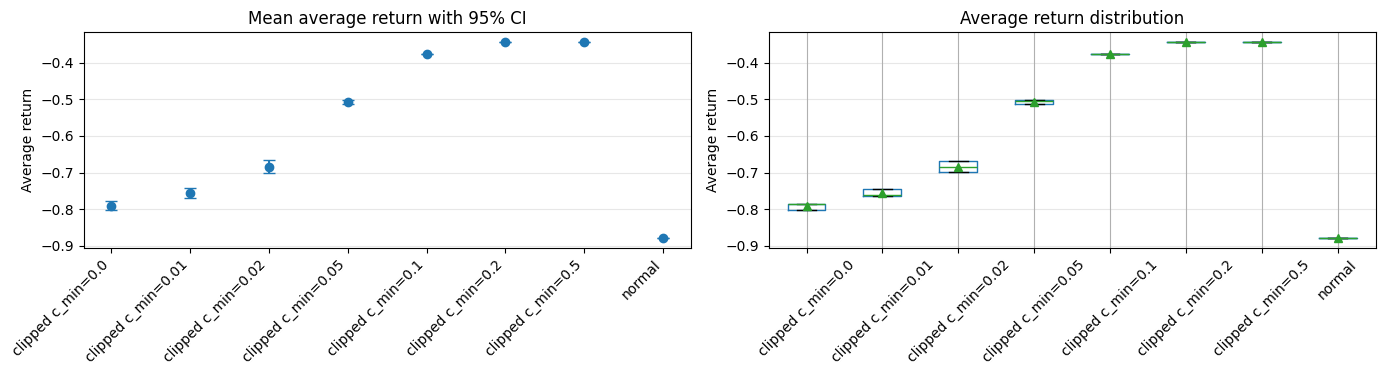

In [51]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Fixed hyperparameters
fixed_params = {
    "alpha": 1e-1,
    "eta": 1e-1,
    "rho": 1e-2,
    "D_theta": 1.0,
    "T": 2000,
}

# Three seeds, including SEED
seeds = [SEED, SEED + 1, SEED + 2]

# One normal/non-clipped baseline + clipped c_min values
configs = [{"state_weight_update": "normal", "c_min": np.nan, "label": "normal"}]
configs += [
    {"state_weight_update": "clipped", "c_min": c, "label": f"clipped c_min={c}"}
    for c in [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
]

rows = []
jobs = [(cfg, run_seed) for cfg in configs for run_seed in seeds]

for cfg, run_seed in tqdm(jobs, desc="c_min seed sweep", unit="run"):
    for run_seed in seeds:
        random.seed(run_seed)
        np.random.seed(run_seed)
        torch.manual_seed(run_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run_seed)

        solver = VBetaObjectivePolicySolver(
            mdp=mdp,
            phi=phi,
            csv_path=dataset_path,
            print_params=False,
            seed=run_seed,
            device=DEVICE,
        )

        evaluator = FOGASEvaluator(
            solver=solver,
            mdp=mdp,
            planner=planner,
        )

        run_kwargs = dict(
            **fixed_params,
            tqdm_print=False,
            verbose=False,
            state_weight_update=cfg["state_weight_update"],
        )

        if cfg["state_weight_update"] == "clipped":
            run_kwargs["c_min"] = float(cfg["c_min"])

        solver.run(**run_kwargs)

        result = evaluator.average_return(
            policy_mode="solver",
            num_trajectories=10,
            max_steps=20,
            seed=run_seed,
            terminal_states=[goal_grid],
            compare_with_optimal=True,
        )

        rows.append({
            "label": cfg["label"],
            "state_weight_update": cfg["state_weight_update"],
            "c_min": cfg["c_min"],
            "seed": run_seed,
            "average_return": result["policy"],
            "optimal_return": result["optimal"],
            "gap": result["difference"],
            **fixed_params,
        })

results_df = pd.DataFrame(rows)

output_path = RESULTS_DIR / "3grid_vbeta_objective_policy_cmin_seed_sweep.csv"
results_df.to_csv(output_path, index=False)

summary_df = (
    results_df
    .groupby(["label", "state_weight_update", "c_min"], dropna=False)
    .agg(
        n=("average_return", "count"),
        mean_return=("average_return", "mean"),
        std_return=("average_return", "std"),
        best_return=("average_return", "max"),
        mean_gap=("gap", "mean"),
    )
    .reset_index()
)

# 95% CI with n=3: t_{0.975,2} ~= 4.303
summary_df["ci95"] = 4.303 * summary_df["std_return"].fillna(0.0) / np.sqrt(summary_df["n"])

best = summary_df.sort_values("mean_return", ascending=False).iloc[0]

print(f"Saved CSV to: {output_path}")
print("\nBest config by mean average return:")
display(best.to_frame().T)

print("\nAll configs:")
display(summary_df.sort_values("mean_return", ascending=False))

plot_df = summary_df.copy()
plot_df["x_label"] = plot_df["label"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["mean_return"],
    yerr=plot_df["ci95"],
    fmt="o",
    capsize=4,
)
axes[0].set_xticks(np.arange(len(plot_df)))
axes[0].set_xticklabels(plot_df["x_label"], rotation=45, ha="right")
axes[0].set_ylabel("Average return")
axes[0].set_title("Mean average return with 95% CI")
axes[0].grid(axis="y", alpha=0.3)

results_df.boxplot(
    column="average_return",
    by="label",
    ax=axes[1],
    showmeans=True,
)
axes[1].set_title("Average return distribution")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average return")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("")
plt.tight_layout()
plt.show()

### Tabular SGD/Adam

In [53]:
policy_features = TabularPolicyFeatures(mdp.N, mdp.A)

solver_e = LinearPolicyFOGAS(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,  # or dataset_path1 if that is the variable you want
    print_params=True,
    seed=SEED,
    device=DEVICE,
    policy_features=policy_features,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "terminal_states": [goal_grid],
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets/3grid.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      462.7564263195183
T (iterations):                463

FOGAS Hyperparameters
---------------------
alpha:                        0.001290
rho:                            812.525089
eta:                            0.000025
D_theta:                    18.973666
beta (ridge):             0.000060
D_pi (derived):           11.330086




In [62]:
solver_e.run(
    alpha=1e-3,
    eta=1e-1,
    rho=1e-2,
    D_theta=1,
    T=2000,
    policy_optimizer="adam",  # or "adam"
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    state_weight_update="clipped",
    c_min=0.1,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

[FOGAS linear-policy] Iter 1/2000 total_loss=-5.000000e-02 policy_objective=-5.000000e-02 theta_norm=1.000000e+00 beta_norm=2.275463e-01 grad_norm=2.277739e+00 policy_grad_norm=0.000000e+00 psi_norm=0.000000e+00 policy_optimizer=adam state_weight_update=clipped state_weight_min=0.000000e+00 state_weight_max=1.000000e-01 policy_state_weight_min=1.000000e-01 policy_state_weight_max=1.000000e-01
[FOGAS linear-policy] Iter 51/2000 total_loss=-2.344148e-03 policy_objective=-9.472717e-02 theta_norm=1.000000e+00 beta_norm=9.858734e+00 grad_norm=1.889122e+00 policy_grad_norm=9.712678e-03 psi_norm=2.790375e-01 policy_optimizer=adam state_weight_update=clipped state_weight_min=-5.408523e-02 state_weight_max=7.956361e-02 policy_state_weight_min=1.000000e-01 policy_state_weight_max=1.000000e-01
[FOGAS linear-policy] Iter 101/2000 total_loss=1.745775e-02 policy_objective=-8.922432e-02 theta_norm=1.000000e+00 beta_norm=1.827875e+01 grad_norm=1.785539e+00 policy_grad_norm=1.029262e-02 psi_norm=5.6810

In this one Adam is not that good as SGD, its a bit unstable. Still with SGD is almost same policy than before!

FOR THESIS:

In [63]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt

alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
policy_optimizers = ["sgd", "adam"]

results = []

for alpha, policy_optimizer in itertools.product(alphas, policy_optimizers):
    print(f"\nRunning alpha={alpha:.0e}, policy_optimizer={policy_optimizer}")

    solver_e.run(
        alpha=alpha,
        eta=1e-1,
        rho=1e-2,
        D_theta=1,
        T=2000,
        policy_optimizer=policy_optimizer,
        tqdm_print=False,
        verbose=False,
        log_interval=50,
        state_weight_update="clipped",
        c_min=0.1,
    )

    metric_result = evaluator_e.average_return(
        policy_mode="solver",
        num_trajectories=10,
        max_steps=20,
        seed=SEED,
        terminal_states=[goal_grid],
    )

    avg_return = metric_result["policy"]

    results.append(
        {
            "alpha": alpha,
            "policy_optimizer": policy_optimizer,
            "average_return": avg_return,
        }
    )

results_df = pd.DataFrame(results)
results_df


Running alpha=1e-05, policy_optimizer=sgd

Running alpha=1e-05, policy_optimizer=adam

Running alpha=1e-04, policy_optimizer=sgd

Running alpha=1e-04, policy_optimizer=adam

Running alpha=1e-03, policy_optimizer=sgd

Running alpha=1e-03, policy_optimizer=adam

Running alpha=1e-02, policy_optimizer=sgd

Running alpha=1e-02, policy_optimizer=adam

Running alpha=1e-01, policy_optimizer=sgd

Running alpha=1e-01, policy_optimizer=adam


,alpha,policy_optimizer,average_return
0,0.00001,sgd,-0.801064
1,0.00001,adam,-0.770175
2,0.00010,sgd,-0.801064
3,0.00010,adam,-0.713834
4,0.00100,sgd,-0.801064
5,0.00100,adam,-0.362927
6,0.01000,sgd,-0.770175
7,0.01000,adam,-0.873904
8,0.10000,sgd,-0.626280
9,0.10000,adam,-0.878423


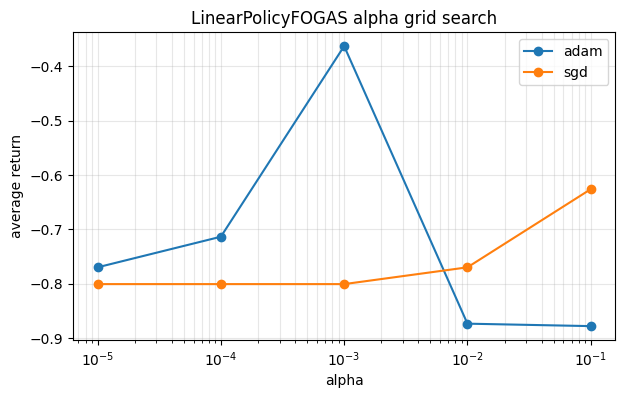

In [64]:
fig, ax = plt.subplots(figsize=(7, 4))

for policy_optimizer, group in results_df.groupby("policy_optimizer"):
    group = group.sort_values("alpha")
    ax.plot(
        group["alpha"],
        group["average_return"],
        marker="o",
        label=policy_optimizer,
    )

ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("average return")
ax.set_title("LinearPolicyFOGAS alpha grid search")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

Best setting

In [65]:
best_row = results_df.loc[results_df["average_return"].idxmax()]
print(best_row)

alpha                  0.001
policy_optimizer        adam
average_return     -0.362927
Name: 5, dtype: object


## Beta update

### Linear $u_{\beta}$ adaptation

In [114]:
u_features = TabularPolicyFeatures(N, A)
policy_features = TabularPolicyFeatures(N, A)

solver_e = LinearBetaPiSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearUFunction(u_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,
)

In [115]:
solver_e.run(
    alpha=2e-2,
    eta=1e-3,
    rho=0.5,
    policy_optimizer="sgd",
    tqdm_print=False,
    verbose=False,
    log_interval=50,
    T=1600,
    state_weight_update="clipped",
    c_min=0.1,
)
mdp.print_policy(solver_e.pi)

  State 0: π(a=0|s=0) = 0.17  π(a=1|s=0) = 0.38  π(a=2|s=0) = 0.10  π(a=3|s=0) = 0.36  --> best action: 1
  State 1: π(a=0|s=1) = 0.23  π(a=1|s=1) = 0.35  π(a=2|s=1) = 0.11  π(a=3|s=1) = 0.32  --> best action: 1
  State 2: π(a=0|s=2) = 0.24  π(a=1|s=2) = 0.32  π(a=2|s=2) = 0.19  π(a=3|s=2) = 0.25  --> best action: 1
  State 3: π(a=0|s=3) = 0.11  π(a=1|s=3) = 0.36  π(a=2|s=3) = 0.23  π(a=3|s=3) = 0.30  --> best action: 1
  State 4: π(a=0|s=4) = 0.16  π(a=1|s=4) = 0.34  π(a=2|s=4) = 0.18  π(a=3|s=4) = 0.32  --> best action: 1
  State 5: π(a=0|s=5) = 0.18  π(a=1|s=5) = 0.41  π(a=2|s=5) = 0.19  π(a=3|s=5) = 0.22  --> best action: 1
  State 6: π(a=0|s=6) = 0.17  π(a=1|s=6) = 0.25  π(a=2|s=6) = 0.24  π(a=3|s=6) = 0.34  --> best action: 3
  State 7: π(a=0|s=7) = 0.20  π(a=1|s=7) = 0.26  π(a=2|s=7) = 0.21  π(a=3|s=7) = 0.34  --> best action: 3
  State 8: π(a=0|s=8) = 0.36  π(a=1|s=8) = 0.36  π(a=2|s=8) = 0.14  π(a=3|s=8) = 0.14  --> best action: 0



## Theta update

### Loss dependency beta regularizer

In [7]:
u_features = TabularPolicyFeatures(N, A)
policy_features = TabularPolicyFeatures(N, A)

solver_e = LossThetaBetaPiSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearUFunction(u_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,
)

In [8]:
solver_e.run(
    alpha=2e-2,
    eta=1e-3,
    rho=0.5,
    policy_optimizer="sgd",
    tqdm_print=False,
    verbose=False,
    log_interval=50,
    T=1600,
    state_weight_update="clipped",
    c_min=0.1,
    theta_loss_include_beta_reg=True,
)
mdp.print_policy(solver_e.pi)

  State 0: π(a=0|s=0) = 0.17  π(a=1|s=0) = 0.38  π(a=2|s=0) = 0.10  π(a=3|s=0) = 0.36  --> best action: 1
  State 1: π(a=0|s=1) = 0.23  π(a=1|s=1) = 0.35  π(a=2|s=1) = 0.11  π(a=3|s=1) = 0.32  --> best action: 1
  State 2: π(a=0|s=2) = 0.24  π(a=1|s=2) = 0.32  π(a=2|s=2) = 0.19  π(a=3|s=2) = 0.25  --> best action: 1
  State 3: π(a=0|s=3) = 0.11  π(a=1|s=3) = 0.36  π(a=2|s=3) = 0.23  π(a=3|s=3) = 0.30  --> best action: 1
  State 4: π(a=0|s=4) = 0.16  π(a=1|s=4) = 0.34  π(a=2|s=4) = 0.18  π(a=3|s=4) = 0.32  --> best action: 1
  State 5: π(a=0|s=5) = 0.18  π(a=1|s=5) = 0.41  π(a=2|s=5) = 0.19  π(a=3|s=5) = 0.22  --> best action: 1
  State 6: π(a=0|s=6) = 0.17  π(a=1|s=6) = 0.25  π(a=2|s=6) = 0.24  π(a=3|s=6) = 0.34  --> best action: 3
  State 7: π(a=0|s=7) = 0.20  π(a=1|s=7) = 0.26  π(a=2|s=7) = 0.21  π(a=3|s=7) = 0.34  --> best action: 3
  State 8: π(a=0|s=8) = 0.36  π(a=1|s=8) = 0.36  π(a=2|s=8) = 0.14  π(a=3|s=8) = 0.14  --> best action: 0



In [9]:
solver_e.run(
    alpha=2e-2,
    eta=1e-3,
    rho=0.5,
    policy_optimizer="sgd",
    tqdm_print=False,
    verbose=False,
    log_interval=50,
    T=1600,
    state_weight_update="clipped",
    c_min=0.1,
    theta_loss_include_beta_reg=False,
)
mdp.print_policy(solver_e.pi)

  State 0: π(a=0|s=0) = 0.17  π(a=1|s=0) = 0.38  π(a=2|s=0) = 0.10  π(a=3|s=0) = 0.36  --> best action: 1
  State 1: π(a=0|s=1) = 0.23  π(a=1|s=1) = 0.35  π(a=2|s=1) = 0.11  π(a=3|s=1) = 0.32  --> best action: 1
  State 2: π(a=0|s=2) = 0.24  π(a=1|s=2) = 0.32  π(a=2|s=2) = 0.19  π(a=3|s=2) = 0.25  --> best action: 1
  State 3: π(a=0|s=3) = 0.11  π(a=1|s=3) = 0.36  π(a=2|s=3) = 0.23  π(a=3|s=3) = 0.30  --> best action: 1
  State 4: π(a=0|s=4) = 0.16  π(a=1|s=4) = 0.34  π(a=2|s=4) = 0.18  π(a=3|s=4) = 0.32  --> best action: 1
  State 5: π(a=0|s=5) = 0.18  π(a=1|s=5) = 0.41  π(a=2|s=5) = 0.19  π(a=3|s=5) = 0.22  --> best action: 1
  State 6: π(a=0|s=6) = 0.17  π(a=1|s=6) = 0.25  π(a=2|s=6) = 0.24  π(a=3|s=6) = 0.34  --> best action: 3
  State 7: π(a=0|s=7) = 0.20  π(a=1|s=7) = 0.26  π(a=2|s=7) = 0.21  π(a=3|s=7) = 0.34  --> best action: 3
  State 8: π(a=0|s=8) = 0.36  π(a=1|s=8) = 0.36  π(a=2|s=8) = 0.14  π(a=3|s=8) = 0.14  --> best action: 0



Here there is not difference at all!

### Regularized update

After some experiments, here best results. Adam better than SGD, important the number of inner loops (at least 10, with 40 is going better now) and has to be adaptive the lambda regularizer, fixed doesnt work!

In [22]:
u_features = TabularPolicyFeatures(N, A)
policy_features = TabularPolicyFeatures(N, A)

solver_e = RegularizedLossThetaBetaPiSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearUFunction(u_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,
)

solver_e.run(
    alpha=2e-2,
    eta=1e-3,
    rho=0.5,
    policy_optimizer="sgd",
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=1600,
    state_weight_update="clipped",
    c_min=0.1,
    theta_loss_include_beta_reg=False,
    # regularized theta solver
    theta_update="adam",
    theta_lambda_mode="adaptive",
    theta_lambda=1.0,
    theta_inner_steps=40,
    theta_lr=1,
)

mdp.print_policy(solver_e.pi)


[FOGAS linear-beta-pi] Iter 1/1600 total_loss=-8.543471e-01 policy_objective=-8.543471e-01 theta_norm=1.708694e+01 beta_norm=1.641063e-02 grad_norm=1.641883e+01 policy_grad_norm=0.000000e+00 psi_norm=0.000000e+00 policy_optimizer=sgd state_weight_update=clipped state_weight_min=0.000000e+00 state_weight_max=1.000000e-01 policy_state_weight_min=1.000000e-01 policy_state_weight_max=1.000000e-01
[FOGAS linear-beta-pi] Iter 51/1600 total_loss=-6.677266e-01 policy_objective=-1.273539e+00 theta_norm=1.838285e+01 beta_norm=6.320910e-01 grad_norm=9.727966e+00 policy_grad_norm=1.440590e-01 psi_norm=7.917085e-02 policy_optimizer=sgd state_weight_update=clipped state_weight_min=1.157951e-04 state_weight_max=9.082547e-02 policy_state_weight_min=1.000000e-01 policy_state_weight_max=1.000000e-01
[FOGAS linear-beta-pi] Iter 101/1600 total_loss=-5.830274e-01 policy_objective=-1.374022e+00 theta_norm=1.826121e+01 beta_norm=9.606397e-01 grad_norm=6.674896e+00 policy_grad_norm=1.990961e-01 psi_norm=2.565

# Linear

In [5]:
u_features = TabularFeatures(N, A)
q_features = TabularFeatures(N, A)
policy_features = TabularFeatures(N, A)

solver_e = LinearSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearFunction(u_features),
    q_function=LinearQFunction(q_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,
    theta_loss_include_beta_reg=False,
    theta_update="adam",
    theta_inner_steps=40,
    theta_lr=1,
    d_theta_scale=1.0,
)

In [5]:
solver_e.run(
    alpha=2e-2,
    eta=1e-3,
    rho=0.5,
    policy_optimizer="sgd",
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=1600,
    state_weight_update="clipped",
    c_min=0.1,
)

mdp.print_policy(solver_e.pi)


[LinearSolver] Iter 1/1600 iter=0 total_loss=-8.543471e-01 policy_objective=-8.543471e-01 beta_objective=0.000000e+00 q_objective=-4.696513e-01 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=8.614954e-01 theta_grad_norm=4.971954e-03 policy_optimizer=sgd policy_gradient=exact policy_direction=sgd_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 51/1600 iter=50 total_loss=-5.998003e-01 policy_objective=-1.407019e+00 beta_objective=1.468544e-01 q_objective=-3.072960e-01 policy_grad_norm=1.809669e-01 policy_direction_norm=1.809669e-01 beta_grad_norm=3.371074e-01 theta_grad_norm=2.877263e-03 policy_optimizer=sgd policy_gradient=exact policy_direction=sgd_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 101/1600 iter=100 total_loss=-5.029753e-01 policy_objective=-1.673591e+00 beta_objective=1.661173e-01 q_objective=-2.545087e-01 policy_grad_norm=1.889202e-0

### Reinforce

Same results!

In [5]:
solver_e.run(
    alpha=2e-2,
    eta=1e-3,
    rho=0.5,
    policy_optimizer="sgd",
    policy_gradient="reinforce",
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=1600,
    state_weight_update="clipped",
    c_min=0.1,
)

mdp.print_policy(solver_e.pi)

[LinearSolver] Iter 1/1600 iter=0 total_loss=-8.543471e-01 policy_objective=-8.543471e-01 beta_objective=0.000000e+00 q_objective=-4.696513e-01 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=5.181960e-01 theta_grad_norm=4.971954e-03 policy_optimizer=sgd policy_gradient=reinforce policy_direction=sgd_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 51/1600 iter=50 total_loss=-6.674529e-01 policy_objective=-1.273464e+00 beta_objective=1.588953e-01 q_objective=-3.440509e-01 policy_grad_norm=1.890286e-01 policy_direction_norm=1.890286e-01 beta_grad_norm=2.774331e-01 theta_grad_norm=3.150502e-03 policy_optimizer=sgd policy_gradient=reinforce policy_direction=sgd_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 101/1600 iter=100 total_loss=-5.817133e-01 policy_objective=-1.375205e+00 beta_objective=1.253105e-01 q_objective=-3.028369e-01 policy_grad_norm=5.4

In [13]:
solver_e.run(
    alpha=1e-3,
    eta=1e-4,
    rho=0.05,
    policy_optimizer="adam",
    policy_gradient="reinforce",
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2500,
    state_weight_update="normal",
    # c_min=0.1,
)

mdp.print_policy(solver_e.pi)

[LinearSolver] Iter 1/2500 iter=0 total_loss=-8.543471e-01 policy_objective=-8.543471e-01 beta_objective=0.000000e+00 q_objective=-4.696513e-01 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=8.614954e-01 theta_grad_norm=4.971954e-03 policy_optimizer=adam policy_gradient=reinforce policy_direction=adam_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 51/2500 iter=50 total_loss=-7.950163e-01 policy_objective=-8.392390e-01 beta_objective=5.785542e-02 q_objective=-4.362361e-01 policy_grad_norm=1.716689e-03 policy_direction_norm=1.716689e-03 beta_grad_norm=8.011312e-01 theta_grad_norm=4.652609e-03 policy_optimizer=adam policy_gradient=reinforce policy_direction=adam_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 101/2500 iter=100 total_loss=-7.438434e-01 policy_objective=-8.260374e-01 beta_objective=1.042607e-01 q_objective=-4.069444e-01 policy_grad_norm

### NPG

With smaller learning rate goes well! Needs maybe more steps but the total loss is going down

In [ ]:
solver_e.run(
    alpha=1e-3,
    eta=1e-3,
    rho=0.5,
    policy_optimizer="npg",
    policy_gradient="reinforce",
    fisher_damping=1e-2,
    cg_iters=40,
    cg_tol=1e-10,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=1600,
    state_weight_update="normal",
    #c_min=0.0,
)

mdp.print_policy(solver_e.pi)

[LinearSolver] Iter 1/1600 iter=0 total_loss=-8.543471e-01 policy_objective=-8.543471e-01 beta_objective=0.000000e+00 q_objective=-4.696513e-01 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=8.614954e-01 theta_grad_norm=4.971954e-03 policy_optimizer=npg policy_gradient=reinforce policy_direction=cg_fisher reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01 cg_iters_used=0 cg_residual_norm=0.000000e+00 cg_relative_residual=0.000000e+00
[LinearSolver] Iter 51/1600 iter=50 total_loss=-6.017055e-01 policy_objective=-7.898988e-01 beta_objective=1.439864e-01 q_objective=-3.080996e-01 policy_grad_norm=4.711100e-02 policy_direction_norm=8.690283e-01 beta_grad_norm=3.336960e-01 theta_grad_norm=2.895888e-03 policy_optimizer=npg policy_gradient=reinforce policy_direction=cg_fisher reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01 cg_iters_used=9 cg_residual_norm=3.519481e-11 cg_relative_residual=7.470614e-10
[LinearSolver]

In [14]:
solver_e.run(
    alpha=1e-3,
    eta=1e-4,
    rho=0.05,
    policy_optimizer="npg",
    policy_gradient="reinforce",
    fisher_damping=1e-2,
    cg_iters=40,
    cg_tol=1e-10,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2500,
    state_weight_update="normal",
    #c_min=0.0,
)

mdp.print_policy(solver_e.pi)

[LinearSolver] Iter 1/2500 iter=0 total_loss=-8.543471e-01 policy_objective=-8.543471e-01 beta_objective=0.000000e+00 q_objective=-4.696513e-01 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=8.614954e-01 theta_grad_norm=4.971954e-03 policy_optimizer=npg policy_gradient=reinforce policy_direction=cg_fisher reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01 cg_iters_used=0 cg_residual_norm=0.000000e+00 cg_relative_residual=0.000000e+00
[LinearSolver] Iter 51/2500 iter=50 total_loss=-7.980725e-01 policy_objective=-8.413855e-01 beta_objective=5.661489e-02 q_objective=-4.370570e-01 policy_grad_norm=1.074949e-02 policy_direction_norm=1.955467e-01 beta_grad_norm=7.853235e-01 theta_grad_norm=4.572039e-03 policy_optimizer=npg policy_gradient=reinforce policy_direction=cg_fisher reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01 cg_iters_used=6 cg_residual_norm=5.573823e-11 cg_relative_residual=5.185199e-09
[LinearSolver]

# Final

In [ ]:
from rl_methods.fogas_generalization import (
    FinalLinearSolver,
    TabularFeatures,
    LinearFunction,
    LinearQFunction,
)

u_features = TabularFeatures(N, A)
q_features = TabularFeatures(N, A)
policy_features = TabularFeatures(N, A)

solver_e = FinalLinearSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearFunction(u_features),
    q_function=LinearQFunction(q_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,

    # Equivalent to theta_loss_include_beta_reg=False
    theta_include_beta_cov=False,

    # Equivalent to old theta_update="adam" with adaptive lambda
    theta_mode="reg_adaptive",
    theta_optimizer="adam",
    theta_inner_steps=40,
    theta_lr=1.0,
    theta_start_mode="zero",

    d_theta_scale=1.0,

    # Equivalent to old beta update
    beta_update="fogas_full",
)

solver_e.run(
    alpha=1e-3,
    eta=1e-4,
    rho=0.05,
    policy_optimizer="adam",
    policy_gradient="reinforce",
    reinforce_samples=1,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2500,
    state_weight_update="normal",
)

mdp.print_policy(solver_e.pi)

[FinalLinearSolver] Iter 1/2500 iter=0 total_loss=-8.543471e-01 policy_objective=-8.543471e-01 beta_objective=0.000000e+00 q_objective=-4.696513e-01 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=8.614954e-01 beta_direction_norm=1.628813e+01 theta_grad_norm=4.971954e-03 theta_norm=1.708694e+01 theta_mode=reg_adaptive theta_optimizer=adam theta_start_mode=zero theta_lambda=2.635231e-03 theta_lr=1.000000e+00 theta_include_beta_cov=False policy_optimizer=adam policy_gradient=reinforce policy_direction=adam_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01 beta_update=fogas_full beta_diag_min=None beta_diag_max=None
[FinalLinearSolver] Iter 51/2500 iter=50 total_loss=-7.952092e-01 policy_objective=-8.393568e-01 beta_objective=5.773561e-02 q_objective=-4.362983e-01 policy_grad_norm=3.344236e-03 policy_direction_norm=3.344236e-03 beta_grad_norm=8.001185e-01 beta_direction_norm=1.514981e+01 theta_grad_norm=4.648222e-03 theta_norm

In [25]:
from rl_methods.fogas_generalization import (
    FinalLinearSolver,
    TabularFeatures,
    LinearFunction,
    LinearQFunction,
)

u_features = TabularFeatures(N, A)
q_features = TabularFeatures(N, A)
policy_features = TabularFeatures(N, A)

solver_e = FinalLinearSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearFunction(u_features),
    q_function=LinearQFunction(q_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,

    theta_include_beta_cov=False,

    theta_mode="reg_fixed",
    theta_lambda=1e-3,
    theta_optimizer="adam",
    theta_inner_steps=40,
    theta_lr=0.3,
    theta_start_mode="warm",

    beta_update="fogas_full",
)

solver_e.run(
    alpha=1e-3,
    eta=1e-4,
    rho=0.05,
    policy_optimizer="adam",
    policy_gradient="reinforce",
    reinforce_samples=1,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2500,
    state_weight_update="normal",
)

mdp.print_policy(solver_e.pi)

[FinalLinearSolver] Iter 1/2500 iter=0 total_loss=-1.126195e+00 policy_objective=-1.126195e+00 beta_objective=0.000000e+00 q_objective=-8.725320e-01 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=1.137741e+00 beta_direction_norm=2.147210e+01 theta_grad_norm=2.747610e-02 theta_norm=2.252390e+01 theta_mode=reg_fixed theta_optimizer=adam theta_start_mode=warm theta_lambda=1.000000e-03 theta_lr=3.000000e-01 theta_include_beta_cov=False policy_optimizer=adam policy_gradient=reinforce policy_direction=adam_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01 beta_update=fogas_full beta_diag_min=None beta_diag_max=None
[FinalLinearSolver] Iter 51/2500 iter=50 total_loss=-1.754472e+00 policy_objective=-1.993909e+00 beta_objective=2.935044e-01 q_objective=-8.768817e-01 policy_grad_norm=4.560201e-02 policy_direction_norm=4.560201e-02 beta_grad_norm=1.636261e+00 beta_direction_norm=3.200756e+01 theta_grad_norm=8.857740e-05 theta_norm=4.

# State-aggregation Features

**Feature Map**

We use a structured linear feature representation over state–action pairs that decomposes into row features, action features, and a terminal indicator.

The state space is a (3 \times 3) grid with
$$
\mathcal{X} = {0,\dots,8}, \quad \mathcal{A} = {0,1,2,3}.
$$

Let $ \text{row}(x) \in \{0,1,2\}$ denote the row index of state (x).
The feature map is defined as
$$
\phi(x,a) \in \mathbb{R}^{d}, \qquad d = 3 * 4 + 1 = 13.
$$

It has the following structure:
$$
\phi(x,a): \; \; (x,a) \;\longrightarrow\; e_{\; \text{row}(x) \; \cdot \; |\mathcal{A}|\; + \; a},
$$

Thus:

* The **first 3 coordinates** encode the row of the grid.
* The **next 4 coordinates** encode the chosen action.
* The **last coordinate** is a terminal-state indicator for the goal state (x=8).

**Reward Weights**

The reward function is linear in the features:
$$
r(x,a) = \phi(x,a)^\top \omega.
$$

The weight vector $\omega \in \mathbb{R}^{8}$ is defined as
$$
\omega =
\begin{bmatrix}
0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 0 \ 1
\end{bmatrix}.
$$

This yields:
$$
r(x,a) =
\begin{cases}
1 & \text{if } x = 8 \;\; (\text{goal state}), \\
0 & \text{otherwise}.
\end{cases}
$$

**Transition Model**

The transition matrix
$$
P \in \mathbb{R}^{(9\cdot 4) \times 9}
$$
is defined such that each row corresponding to $(x,a)$ contains a single 1 at column $x'$:

$$
P_{(x,a),x'} =
\begin{cases}
1 & \text{if } x' = \text{next\_state}(x,a), \\
0 & \text{otherwise}.
\end{cases}
$$


## Testing

In [19]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)
N = len(states) # number of states
A = len(actions) # number of actions
gamma = 0.9

x_0 = 0 # fixed initial state
dataset_path = str(DATASETS_DIR / "grid3_sa_gen.csv") 

goal = 8   # absorbing terminal state

# Helper to convert index <-> (row, col)
def to_rc(s):  return divmod(int(s), 3)
def to_s(r,c): return r*3 + c

d = (N // 3) * A + 1   # 3*4 + 1 = 13

def phi(state, action):
    r, _ = to_rc(state)
    f = torch.zeros(d, dtype=torch.float64)
    f[r * A + int(action)] = 1.0
    f[-1] = 1.0 if int(state) == goal else 0.0
    return f

omega = torch.zeros(d, dtype=torch.float64)
omega[d - 1] = 1.0

def next_state(s, a):
    s = int(s)
    a = int(a)
    if s == goal:
        return goal  # absorbing: if we reach that state we stay in that state

    r, c = to_rc(s)

    if a == 0:  # Up
        r = max(0, r-1)
    elif a == 1:  # Down
        r = min(2, r+1)
    elif a == 2:  # Left
        c = max(0, c-1)
    elif a == 3:  # Right
        c = min(2, c+1)

    return to_s(r, c)

P_grid = torch.zeros((N * A, N), dtype=torch.float64)
count = 0
for x in range(N):
    for a in range(A):
        xp = next_state(x, a)     # deterministic next state
        for xp_ in range(N):
            if xp_ == xp:
                P_grid[count, xp_] = 1.0
            else:
                P_grid[count, xp_] = 0.0
        count += 1

mdp = PolicySolver(states=states, actions=actions, phi=phi, omega=omega, gamma=gamma, x0=x_0, P=P_grid)

In [44]:
collector = EnvDataCollector(
    mdp=mdp,
    max_steps=30,
    terminal_states=[goal],
    seed=42,
)

df = collector.collect_mixed_dataset(
    policies=[mdp.pi_star, "random"],   # optimal + random
    proportions=[0.9, 0.1],            # 90% optimal, 10% random
    n_steps=1000,
    save_path=dataset_path,
    verbose=True,
    episode_based=True,                
)



  MIXED DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 1000
Total episodes: 192
Mode: Episode-based

Policy Distribution:
  Policy 0:   707 steps (70.7%) | Target: 90.0% | Episodes: 177
  Policy 1:   293 steps (29.3%) | Target: 10.0% | Episodes: 16

✅ Mixed dataset saved to: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/grid3_sa_gen.csv


### Empirical

In [45]:
solver_e = FOGASSolverBetaVectorized(mdp=mdp, print_params=True, csv_path=dataset_path, seed=SEED, device=DEVICE)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"))



Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/grid3_sa_gen.csv (n=1000)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           1000
Feature norm bound R:     1.4142
Num states N:             9
Num actions A:            4
Feature dim d:            13
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      1851.025705278074
T (iterations):                1852

FOGAS Hyperparameters
---------------------
alpha:                        0.000759
rho:                            221.625558
eta:                            0.000024
D_theta:                    11.401754
beta (ridge):             0.000083
D_pi (derived):           16.023162




Trying same optimal hyperparameters found for the oracle.

In [54]:
solver_e.run(alpha=2e-3, eta=1e-4, rho=0.5, tqdm_print=True, T = 2000)
evaluator_e.compare_value_functions()
evaluator_e.compare_final_rewards()
evaluator_e.print_policy()

FOGAS:   0%|          | 0/2000 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 2000/2000 [00:01<00:00, 1655.07it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  6.561000 | V^π(x) =  3.371634 | Δ = -3.189366e+00
State 1: V*(x) =  7.290000 | V^π(x) =  4.547496 | Δ = -2.742504e+00
State 2: V*(x) =  8.100000 | V^π(x) =  6.491064 | Δ = -1.608936e+00
State 3: V*(x) =  7.290000 | V^π(x) =  3.737561 | Δ = -3.552439e+00
State 4: V*(x) =  8.100000 | V^π(x) =  5.173964 | Δ = -2.926036e+00
State 5: V*(x) =  9.000000 | V^π(x) =  7.861713 | Δ = -1.138287e+00
State 6: V*(x) =  8.100000 | V^π(x) =  4.086976 | Δ = -4.013024e+00
State 7: V*(x) =  9.000000 | V^π(x) =  5.853301 | Δ = -3.146699e+00
State 8: V*(x) =  10.000000 | V^π(x) =  10.000000 | Δ =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.904900 | Q^π(x,a) =  3.034470 | Δ = -2.870430e+00
(x=0, a=1): Q*(x,a) =  6.561000 | Q^π(x,a) =  3.363805 | Δ = -3.197195e+00
(x=0, a=2): Q*(x,a) =  5.904900 | Q^π(x,a) =  3.034470 | Δ = -2.870430e+00
(x=0, a=3): Q*(x,a) =  6.561000 | Q^π(x,a) =  4.092746 | Δ